<a href="https://colab.research.google.com/github/Farhana-Tani/Training_Yolo26_Instance_Segmentation/blob/main/Training_Yolo26_Instance_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Training costom datasets with Yolo26

In [1]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


## Dataset Preparation

In [2]:
%cd /content/drive/MyDrive/Yolo_Datasets

/content/drive/MyDrive/Yolo_Datasets


## Using the Command Line Interface

In [4]:
!unzip /content/drive/MyDrive/Yolo_Datasets/rock-paper-scissors.v14i.yolo26.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-212_jpg.rf.1e8561703c71365c0fed5b3bf9ae055c.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-212_jpg.rf.6d343393e00bb5cdd53ba41620c2805d.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-212_jpg.rf.7653f90d0a71d91fb45908be2cfb2ef9.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-214_jpg.rf.14f2adf12c2c9bc458d9495b8ec61076.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-214_jpg.rf.6d5bc1bd3db6b53f0951763b33f8fe3c.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-214_jpg.rf.9fe36597c1505ea00935f4d1e1285ded.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-215_jpg.rf.323f75af9cc2a439a8ed0b738864b30c.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-215_jpg.rf.7e7e0e3f1698

## Starting the Training Procedure

In [6]:
# Train YOLO26 on rock paper scissors dataset for 2 epochs
!yolo train model=yolo26m.pt data="/content/drive/MyDrive/Yolo_Datasets/data.yaml" epochs=2 imgsz=640

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Yolo_Datasets/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64,

## Validating the Trained Model

In [10]:
# Validate Trained model on validation Set
!yolo val model="/content/drive/MyDrive/Yolo_Datasets/runs/detect/train-2/weights/best.pt" data="/content/drive/MyDrive/Yolo_Datasets/data.yaml"

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.2 ms, read: 10.9±6.7 MB/s, size: 23.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Yolo_Datasets/valid/labels.cache... 576 images, 238 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 576/576 63.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 1.9it/s 19.0s
                   all        576        400      0.719      0.612      0.687      0.411
                 Paper        132        139      0.605      0.573      0.575      0.319
                  Rock        121        141      0.778      0.672      0.754      0.476
              Scissors        116        120  

## Inferencing with our trained Model

In [11]:
# Visualize the predicted image function
import cv2
from google.colab.patches import cv2_imshow

def show_image(image_path):
  """
  Function to display an image using Opencv in google colab.

  Parameters:
  image_path (str): Path to the image file.
  """
  image=cv2.imread(image_path)
  if image is None:
    print("Error: Image not found")
    return
  cv2_imshow(image)

In [12]:
# Inferencing with our trained model
!yolo predict model="/content/drive/MyDrive/Yolo_Datasets/runs/detect/train-2/weights/best.pt" source="/content/drive/MyDrive/Yolo_Datasets/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg"

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs

image 1/1 /content/drive/MyDrive/Yolo_Datasets/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg: 640x640 2 Rocks, 37.7ms
Speed: 3.0ms preprocess, 37.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/Yolo_Datasets/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


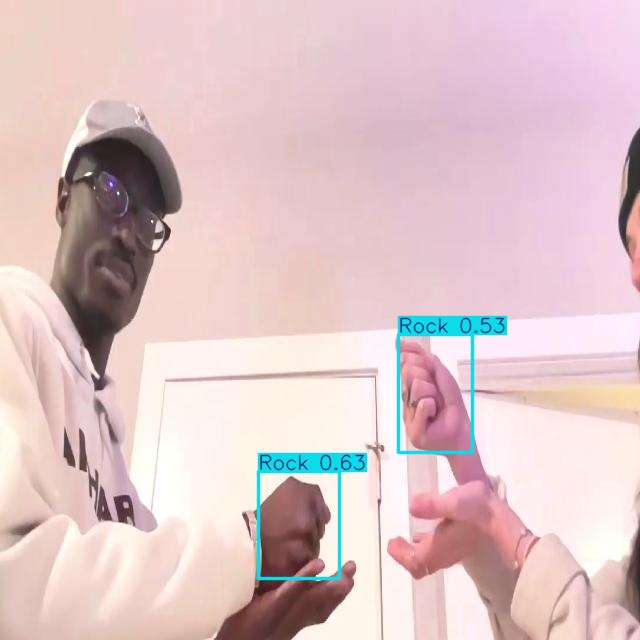

In [16]:
show_image("/content/drive/MyDrive/Yolo_Datasets/runs/detect/predict/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg")

## Exporting in ONNX for faster Inferencing Speeds on CPU

In [14]:
!yolo export model="/content/drive/MyDrive/Yolo_Datasets/runs/detect/train-2/weights/best.pt" format=onnx

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Yolo_Datasets/runs/detect/train-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (42.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 532ms
Prepared 4 packages in 3.46s
Installed 4 packages in 400ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.28.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 5.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.2

## Exporting in TensorRT for faster Inferencing Speeds on GPU

In [15]:
!yolo export model=yolo26n.pt format=engine

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs

PyTorch: starting from 'yolo26n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.3 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 18 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.1s, saved as 'yolo26n.onnx' (9.5 MB)
requirements: Ultralytics requirement ['tensorrt-cu12>=7.0.0,!=10.2.0'] not

## Python Usage

In [17]:
from ultralytics import YOLO

# Load our trained model
model = YOLO('yolo26n.pt')  # load a pretrained model (recommended for training)

# Use the model
results = model.train(data='/content/drive/MyDrive/Yolo_Datasets/data.yaml', epochs=1)  # train the model
#results = model.val()  # evaluate model performance on the validation set
#results = model('/content/drive/MyDrive/Yolo_Datasets/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg')  # predict on an image
#results = model.export(format='onnx')  # export the model to ONNX format
#results = model.export(format='engine')

New https://pypi.org/project/ultralytics/8.4.106 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Yolo_Datasets/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup

In [19]:
from ultralytics import YOLO


model1 = YOLO("/content/drive/MyDrive/Yolo_Datasets/runs/detect/train-2/weights/best.pt")
source = ""
results = model('/content/drive/MyDrive/Yolo_Datasets/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg')


image 1/1 /content/drive/MyDrive/Yolo_Datasets/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg: 640x640 1 Rock, 14.6ms
Speed: 2.6ms preprocess, 14.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
